# Semana 2 — ARIMA, estacionariedad y diagnóstico

**Objetivo.** Dominar el ciclo Box–Jenkins: identificación, estimación, selección y diagnóstico; usar validación para hiperparámetros y test una sola vez.

- **Dataset:** `data/02_energy/energy.csv`
- **Target:** `y`, energía de electrodomésticos
- **Duración:** 4–5 horas
- **Seed:** 42

> Para que ARIMA estacional sea ejecutable en CPU, la serie de 10 minutos se agrega a energía horaria por suma. Las covariables se conservan para discutir ARIMAX.

**Contrato de secciones:** Sección 0: Configuración y contrato de datos; Sección 1: Análisis previo; Sección 2: Estrategia de validación; Sección 3: Modelado; Sección 4: Análisis posterior; Sección 5: Lecciones metodológicas; Sección 6: Ejercicios.

## Caso de negocio: gestión de demanda energética de electrodomésticos

**Contexto.** El dataset Appliances Energy registra el consumo eléctrico de electrodomésticos en una vivienda (target `y`, energía por intervalo de 10 minutos, agregada luego a energía horaria). En gestión de demanda, pronosticar este consumo alimenta tres decisiones operativas:

- **Dimensionamiento:** anticipar el consumo esperado para dimensionar compras de energía, baterías o contratos; un error sistemático se traduce en sobrecoste o capacidad ociosa.
- **Alertas de pico:** anticipar las horas de consumo máximo permite activar respuestas de demanda (desplazamiento de carga, generación propia) y evitar penalizaciones por potencia contratada.
- **Presupuesto y tarificación:** el costo del error es asimétrico: subestimar un pico suele ser más caro que sobreestimar un valle.

**Pregunta guía de la semana:** ¿Un modelo estadístico con diagnóstico de residuos (ARIMA) supera a un baseline estacional (seasonal naive de 24 horas)? La respuesta se construye con evidencia en la Sección 3 (Modelado) y la Sección 4 (Análisis posterior).

> **Pausa para pensar.** Antes de modelar, formule su hipótesis: ¿qué modelo espera ganar en MASE sobre el test y por qué? Anótela; al final del notebook comparará su intuición con la evidencia.

> **¿Para quién importa este pronóstico?** Quien gestiona la vivienda usa el pronóstico horario de consumo para dimensionar contratos de potencia, anticipar picos y detectar anomalías (posible falla de un electrodoméstico o uso ineficiente). Un error sistemático en horas pico puede traducirse en penalizaciones tarifarias o sobrecostos de capacidad contratada.

### 0.1 Imports y seed

El notebook usa solo librerías declaradas y fija toda aleatoriedad. La semilla (`seed=42`) se define aquí para que cualquier componente estocástico (inicialización de modelos, arranques de optimización) sea reproducible: misma semilla, mismos resultados. Si se cambiara, los números podrían variar aunque la metodología fuera idéntica.

In [1]:
# Imports estándar y de terceros para series temporales
# Se fija la semilla (seed) para reproducibilidad
from __future__ import annotations
from pathlib import Path
from itertools import product
import random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from statsforecast import StatsForecast
from statsforecast.models import Theta
SEED=42
random.seed(SEED); np.random.seed(SEED)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid",context="notebook")
plt.rcParams["figure.figsize"]=(12,4)

### 0.2 Ruta portable

Funciona desde raíz o desde `notebooks/`. Así el notebook puede ejecutarse en ambos lugares sin romper la referencia al CSV del dataset (`data/02_energy/energy.csv`).

In [2]:
# Rutas candidatas: raíz del repo o subcarpeta notebooks/
# Se elige la primera ruta que exista; si ninguna existe, el assert falla
CANDIDATES=[Path("data/02_energy/energy.csv"),Path("../data/02_energy/energy.csv")]
DATA_PATH=next((p for p in CANDIDATES if p.exists()),None)
assert DATA_PATH is not None
print(DATA_PATH.resolve())

/home/enrique/Escritorio/Curso_pronostico_series_temporales/course-timeseries-benchmarks-pro/data/02_energy/energy.csv


### 0.3 Carga

Se validan 19,735 filas y 29 columnas: `ds` (timestamp), `y` (energía de electrodomésticos) y el resto de sensores y covariables del entorno. La forma exacta queda fijada por una aserción en la celda siguiente.

In [3]:
# Lectura del CSV con parseo de fechas: ds se convierte a datetime
# El assert fija la forma esperada por el contrato (19,735 filas, 29 columnas)
raw=pd.read_csv(DATA_PATH,parse_dates=["ds"])
assert raw.shape==(19_735,29),raw.shape
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   ds           19735 non-null  datetime64[ns]
 1   y            19735 non-null  int64         
 2   lights       19735 non-null  int64         
 3   t1           19735 non-null  float64       
 4   rh_1         19735 non-null  float64       
 5   t2           19735 non-null  float64       
 6   rh_2         19735 non-null  float64       
 7   t3           19735 non-null  float64       
 8   rh_3         19735 non-null  float64       
 9   t4           19735 non-null  float64       
 10  rh_4         19735 non-null  float64       
 11  t5           19735 non-null  float64       
 12  rh_5         19735 non-null  float64       
 13  t6           19735 non-null  float64       
 14  rh_6         19735 non-null  float64       
 15  t7           19735 non-null  float64       
 16  rh_7

### 0.4 Contrato

`ds` es único y `y` numérico no negativo. Antes de analizar se fija el contrato de datos: si el dataset cambiara, las aserciones avisarían de inmediato en vez de contaminar silenciosamente el modelo.

In [4]:
# Contrato mínimo de datos: orden temporal, unicidad, tipo numérico y no negatividad
assert raw.ds.is_monotonic_increasing
assert raw.ds.is_unique
assert pd.api.types.is_numeric_dtype(raw.y)
assert (raw.y>=0).all()
print("Contrato básico: OK")

Contrato básico: OK


### 0.5 Nulos

No se imputa antes de auditar. Primero se cuantifica cuánto y dónde falta; la imputación (si procede) se decide después, conociendo el alcance del problema.

In [5]:
# Conteo de nulos por columna y porcentaje sobre el total de filas
nulls=raw.isna().sum().to_frame("n_missing"); nulls["pct"]=100*nulls.n_missing/len(raw); nulls.query("n_missing>0")

,n_missing,pct


### 0.6 Duplicados

Se revisan dos tipos de duplicados: filas idénticas (registro repetido) y timestamps repetidos (dos mediciones en el mismo instante). Ambos distorsionan la frecuencia y el cómputo de la serie.

In [6]:
# Duplicados de filas y de timestamps: son problemas distintos
print("Filas duplicadas:",raw.duplicated().sum()); print("Timestamps duplicados:",raw.ds.duplicated().sum())

Filas duplicadas: 0
Timestamps duplicados: 0


### 0.7 Rango y frecuencia

La serie es regular a 10 minutos. Se confirma el rango temporal y la frecuencia de muestreo antes de agregar: una frecuencia irregular obligaría a re-muestrear primero.

In [7]:
# Deltas entre timestamps consecutivos: la moda confirma la frecuencia de muestreo
delta=raw.ds.diff().dropna(); print(raw.ds.min(),raw.ds.max()); print(delta.value_counts().head())

2016-01-11 17:00:00 2016-05-27 18:00:00
ds
0 days 00:10:00    19734
Name: count, dtype: int64


### 0.8 Gaps

Se compara con rejilla completa. La diferencia entre la rejilla esperada y los timestamps observados revela huecos que podrían romper el supuesto de regularidad.

In [8]:
# Rejilla completa esperada a 10 minutos vs timestamps observados
expected=pd.date_range(raw.ds.min(),raw.ds.max(),freq="10min")
missing=expected.difference(raw.ds); print("Esperadas",len(expected),"observadas",raw.ds.nunique(),"gaps",len(missing))

Esperadas 19735 observadas 19735 gaps 0


### 0.9 Estadísticos del target

La distribución de energía tiene cola derecha (pocas horas de consumo muy alto). Esto anticipa dos decisiones: comparar modelos en nivel y en log1p, y esperar errores grandes en los picos.

In [9]:
# Percentiles amplios: la cola derecha se aprecia en la distancia entre p99 y la mediana
raw.y.describe(percentiles=[.01,.25,.5,.75,.95,.99]).to_frame().T

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
y,19735.0,97.694958,102.524891,10.0,20.0,50.0,60.0,100.0,330.0,576.6,1080.0


### 0.10 Agregación horaria

`y` y `lights` son energía por intervalo y se suman; los sensores continuos (temperatura, humedad, etc.) se promedian. La agregación reduce 6 filas de 10 minutos a 1 fila horaria y hace viable ARIMA estacional en CPU.

In [10]:
# Columnas de energía (se suman) y sensores (se promedian) al agregar a hora
# Verificación post-agregación: índice único y target sin nulos
energy_cols=["y","lights"]; sensor_cols=[x for x in raw.columns if x not in ["ds",*energy_cols]]
hourly=pd.concat([raw.set_index("ds")[energy_cols].resample("1h").sum(),raw.set_index("ds")[sensor_cols].resample("1h").mean()],axis=1)
assert hourly.index.is_unique and hourly.y.notna().all()
print(hourly.shape,hourly.index.min(),hourly.index.max())

(3290, 28) 2016-01-11 17:00:00 2016-05-27 18:00:00


### 0.11 Visualización completa

Target horario en Wh por hora. La mirada global muestra estacionalidad diaria y semanal, además de picos; esa estructura es la que los modelos deberán capturar.

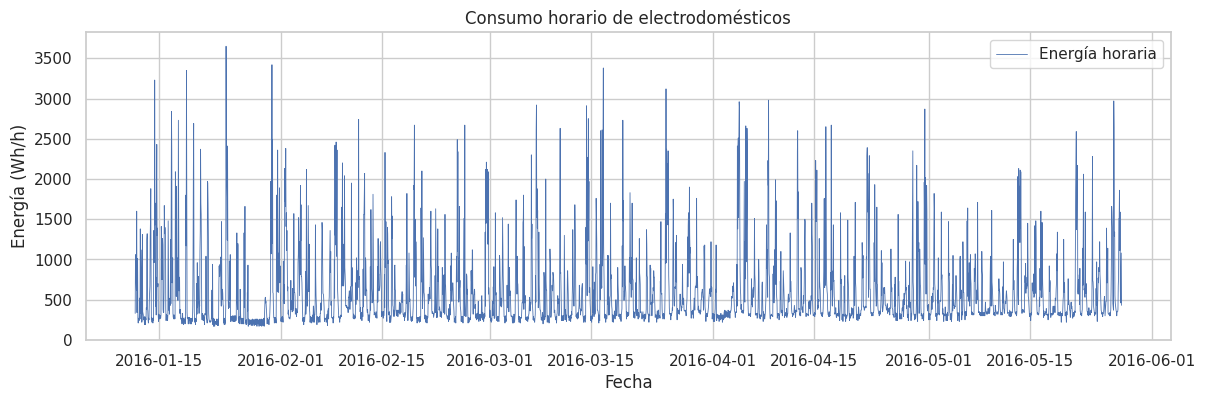

In [11]:
# Serie completa: se aprecian estacionalidad diaria y picos
fig,ax=plt.subplots(figsize=(14,4)); ax.plot(hourly.index,hourly.y,lw=.6,label="Energía horaria")
ax.set(title="Consumo horario de electrodomésticos",xlabel="Fecha",ylabel="Energía (Wh/h)"); ax.legend(); plt.show()

## 1. Análisis previo (pre-modeling)

Se estudian escala, periodicidad, estacionariedad y cambios antes de fijar órdenes ARIMA. Esta sección no ajusta ningún modelo: genera evidencia descriptiva para justificar transformaciones y órdenes candidatos.

### 1.1 Distribución

La cola y los picos motivan comparar nivel y log1p. Si la distribución es muy asimétrica, modelar en log puede estabilizar la varianza, a costa de interpretar el error en otra escala.

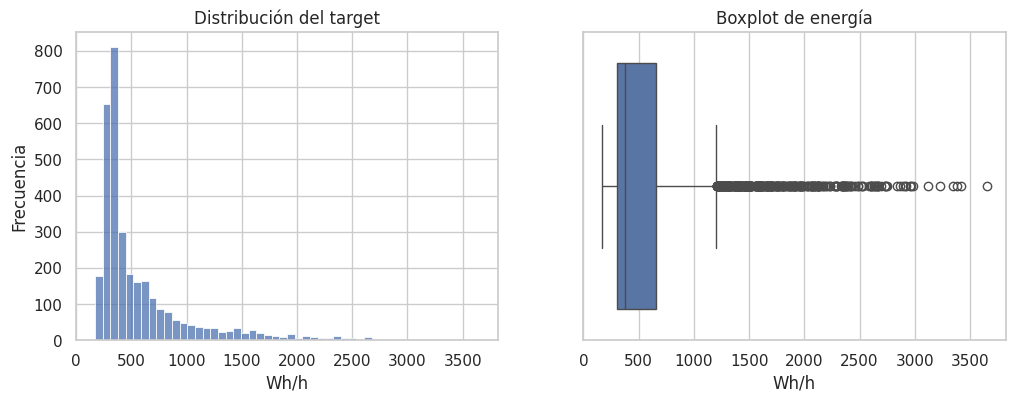

In [12]:
# Histograma y boxplot: asimetría y valores extremos del target
fig,axes=plt.subplots(1,2,figsize=(12,4)); sns.histplot(hourly.y,bins=50,ax=axes[0]); axes[0].set(title="Distribución del target",xlabel="Wh/h",ylabel="Frecuencia"); sns.boxplot(x=hourly.y,ax=axes[1]); axes[1].set(title="Boxplot de energía",xlabel="Wh/h"); plt.show()

### 1.2 Perfil horario

Media y mediana exponen picos por hora. El consumo no es constante a lo largo del día: el modelo necesita estructura estacional o regresores horarios para no perder esta señal.

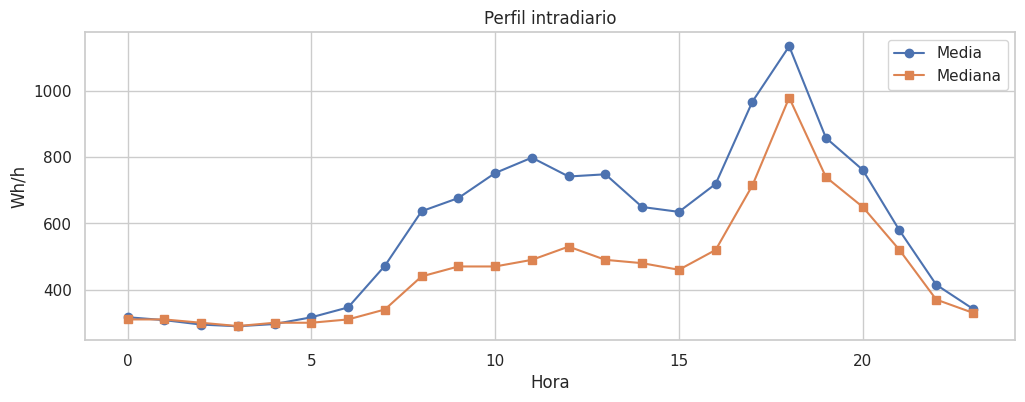

In [13]:
# Perfil intradiario: media y mediana por hora del día
profile=hourly.assign(hour=hourly.index.hour).groupby("hour").y.agg(["mean","median"])
fig,ax=plt.subplots(); ax.plot(profile.index,profile["mean"],marker="o",label="Media"); ax.plot(profile.index,profile["median"],marker="s",label="Mediana"); ax.set(title="Perfil intradiario",xlabel="Hora",ylabel="Wh/h"); ax.legend(); plt.show()

### 1.3 Perfil semanal

Se compara el consumo medio por día de la semana. El objetivo es detectar si el fin de semana se comporta distinto (patrón laboral) y si conviene tratarlo como estacionalidad semanal.

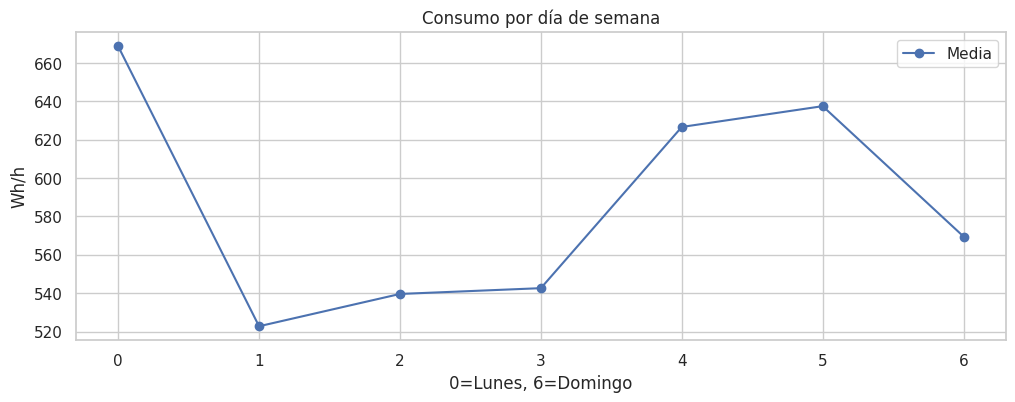

In [14]:
# Consumo medio por día de la semana (0=lunes ... 6=domingo)
prof=hourly.assign(dow=hourly.index.dayofweek).groupby("dow").y.mean(); fig,ax=plt.subplots(); ax.plot(prof.index,prof,marker="o",label="Media"); ax.set(title="Consumo por día de semana",xlabel="0=Lunes, 6=Domingo",ylabel="Wh/h"); ax.legend(); plt.show()

### 1.4 STL diario

STL robusta con periodo 24 descompone la serie en tendencia, estacionalidad diaria y residuo. El modo robusto reduce la influencia de outliers al estimar los componentes.

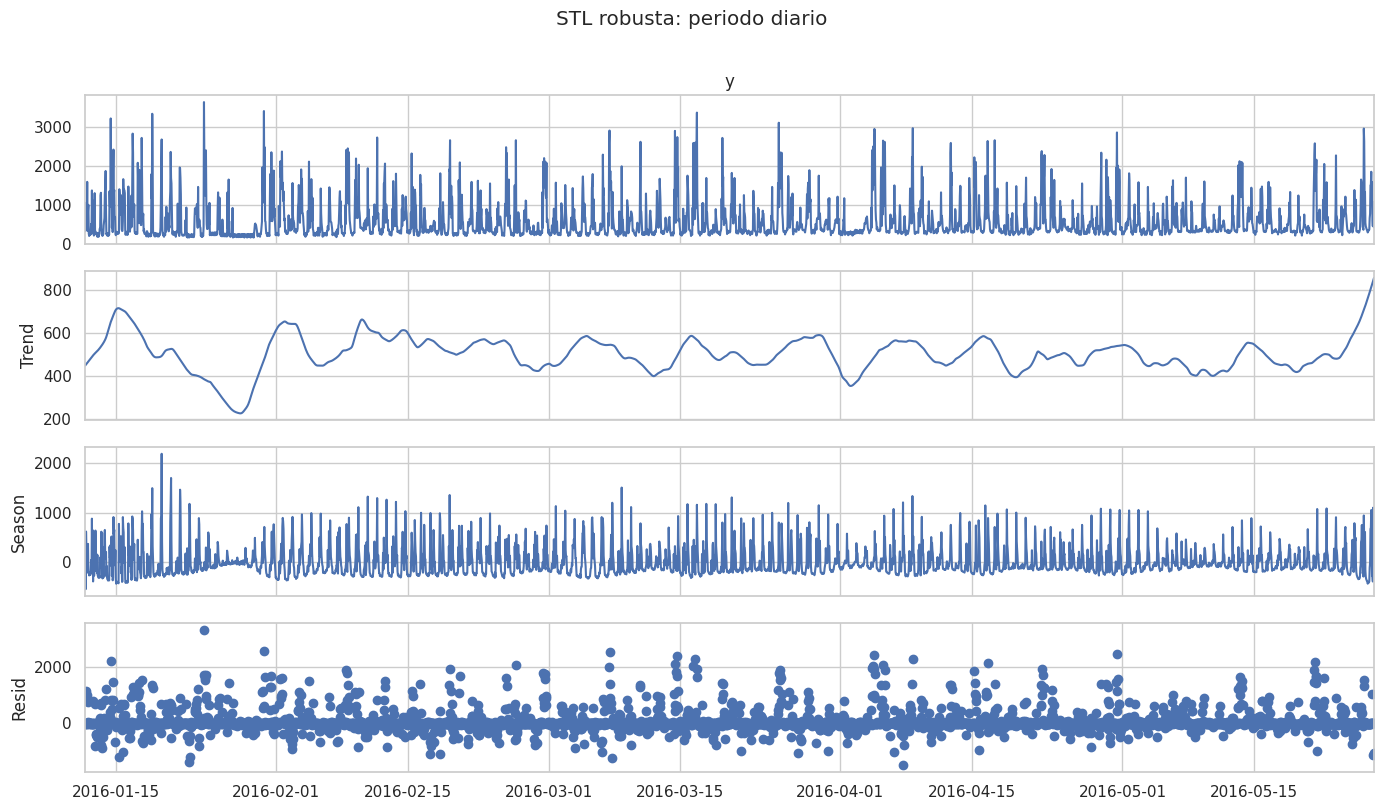

In [15]:
# Descomposición STL robusta: tendencia + estacionalidad (periodo 24h) + residuo
stl=STL(hourly.y,period=24,robust=True).fit(); fig=stl.plot(); fig.set_size_inches(14,8); fig.suptitle("STL robusta: periodo diario",y=1.01); plt.tight_layout(); plt.show()

### 1.5 Outliers

MAD del residuo STL con umbral 4.5. Se marcan residuos a más de 4.5 desviaciones absolutas medianas de la mediana: un criterio robusto, menos sensible a los propios outliers que la desviación estándar.

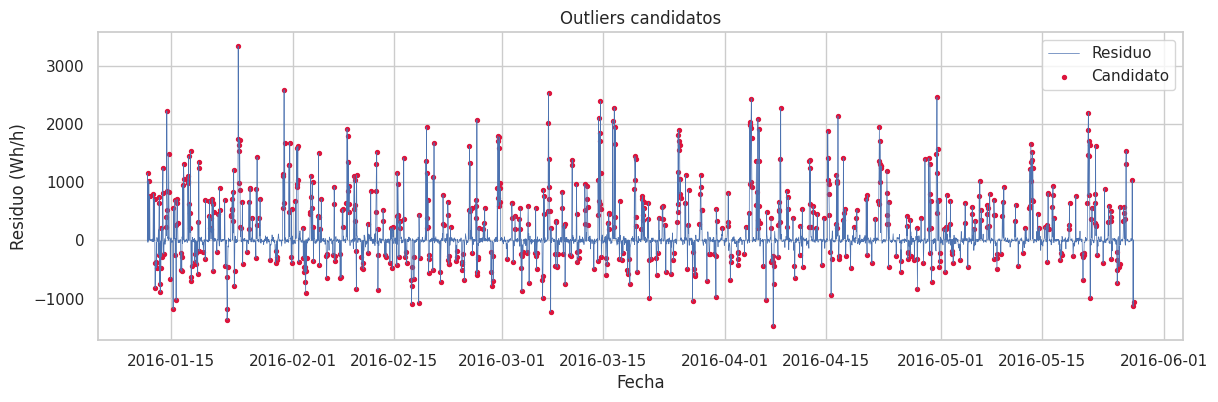

769


In [16]:
# Outliers robustos: residuo estandarizado por MAD con umbral 4.5
med=np.median(stl.resid); mad=np.median(np.abs(stl.resid-med)); rz=.6745*(stl.resid-med)/mad; out=stl.resid[np.abs(rz)>4.5]
fig,ax=plt.subplots(figsize=(14,4)); ax.plot(stl.resid.index,stl.resid,lw=.5,label="Residuo"); ax.scatter(out.index,out,s=8,color="crimson",label="Candidato"); ax.set(title="Outliers candidatos",xlabel="Fecha",ylabel="Residuo (Wh/h)"); ax.legend(); plt.show(); print(len(out))

### 1.6 CUSUM

Cambio acumulado de residuos estandarizados. El CUSUM detecta cambios de nivel: si el consumo cambió de régimen a mitad de la muestra, la suma acumulada se aleja de cero y se mantiene alejada.

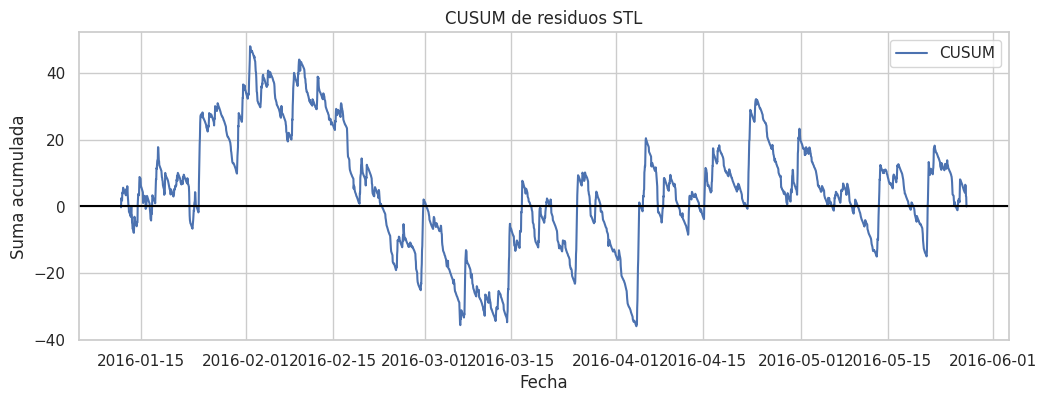

Máxima desviación: 2016-02-01 15:00:00


In [17]:
# CUSUM de residuos estandarizados: detecta cambios de nivel
z=(stl.resid-stl.resid.mean())/stl.resid.std(); cs=z.cumsum(); fig,ax=plt.subplots(); ax.plot(cs.index,cs,label="CUSUM"); ax.axhline(0,color="black"); ax.set(title="CUSUM de residuos STL",xlabel="Fecha",ylabel="Suma acumulada"); ax.legend(); plt.show(); print("Máxima desviación:",cs.abs().idxmax())

### 1.7 Tests de estacionariedad y helper estadístico

- **ADF H₀:** raíz unitaria (serie no estacionaria).
- **KPSS H₀:** estacionariedad alrededor de constante.
- Decisión: rechazar H₀ si *p* < α=0.05.

Los dos tests se complementan: ADF rechaza la raíz unitaria cuando la serie es estacionaria; KPSS rechaza la estacionariedad cuando no lo es. El helper `stationarity_report` reporta hipótesis, estadístico, p-value y decisión, y se reutilizará en nivel, diferencia regular y diferencia diaria.

In [18]:
# Helper reutilizable de estacionariedad: ADF + KPSS con hipótesis, p-value y decisión
def stationarity_report(x: pd.Series,label: str,alpha: float=.05)->pd.DataFrame:
    x=x.dropna().astype(float); a=adfuller(x,autolag="AIC"); k=kpss(x,regression="c",nlags="auto")
    return pd.DataFrame([{"test":"ADF","serie":label,"H0":"raíz unitaria","stat":a[0],"p_value":a[1],"decision":"rechazar H0" if a[1]<alpha else "no rechazar H0"},{"test":"KPSS","serie":label,"H0":"estacionaria","stat":k[0],"p_value":k[1],"decision":"rechazar H0" if k[1]<alpha else "no rechazar H0"}])
stationarity_report(hourly.y,"nivel")

,test,serie,H0,stat,p_value,decision
0,ADF,nivel,raíz unitaria,-9.126898,3.096153e-15,rechazar H0
1,KPSS,nivel,estacionaria,0.041568,1.000000e-01,no rechazar H0


### 1.8 

Diferencia regular yₜ−yₜ₋₁. Si el nivel no es estacionario, la diferencia de orden 1 suele eliminar la tendencia; el test se repite sobre la serie diferenciada para decidir d=1.

In [19]:
# Diferencia regular de orden 1: elimina tendencia si la hay
d1=hourly.y.diff().dropna(); stationarity_report(d1,"diferencia regular")

,test,serie,H0,stat,p_value,decision
0,ADF,diferencia regular,raíz unitaria,-16.907035,1.017406e-29,rechazar H0
1,KPSS,diferencia regular,estacionaria,0.017656,1.000000e-01,no rechazar H0


### 1.9 

Diferencia diaria yₜ−yₜ₋₂₄. Elimina el ciclo diario y es la base para decidir si se necesita un componente estacional explícito (SARIMA en ejercicios).

In [20]:
# Diferencia estacional de 24 horas (un día completo)
d24=hourly.y.diff(24).dropna(); stationarity_report(d24,"diferencia diaria")

,test,serie,H0,stat,p_value,decision
0,ADF,diferencia diaria,raíz unitaria,-13.645961,1.619478e-25,rechazar H0
1,KPSS,diferencia diaria,estacionaria,0.006508,1.000000e-01,no rechazar H0


### 1.10 

log1p evita log(0) cuando hay ceros. Al modelar en log, el error se interpreta en escala multiplicativa (porcentual) y no aditiva; el cambio de interpretación debe explicitarse al comunicar resultados de negocio.

In [21]:
# log1p + diferencia: estabiliza varianza y elimina tendencia
logd=np.log1p(hourly.y).diff().dropna(); stationarity_report(logd,"log-diferencia")

,test,serie,H0,stat,p_value,decision
0,ADF,log-diferencia,raíz unitaria,-16.618455,1.706384e-29,rechazar H0
1,KPSS,log-diferencia,estacionaria,0.012783,1.000000e-01,no rechazar H0


### 1.11 

Nivel, diferencia y log-diferencia en una ventana común. El nivel conserva la escala de negocio (Wh/h); la diferencia y la log-diferencia muestran si la variación es estable a lo largo del tiempo.

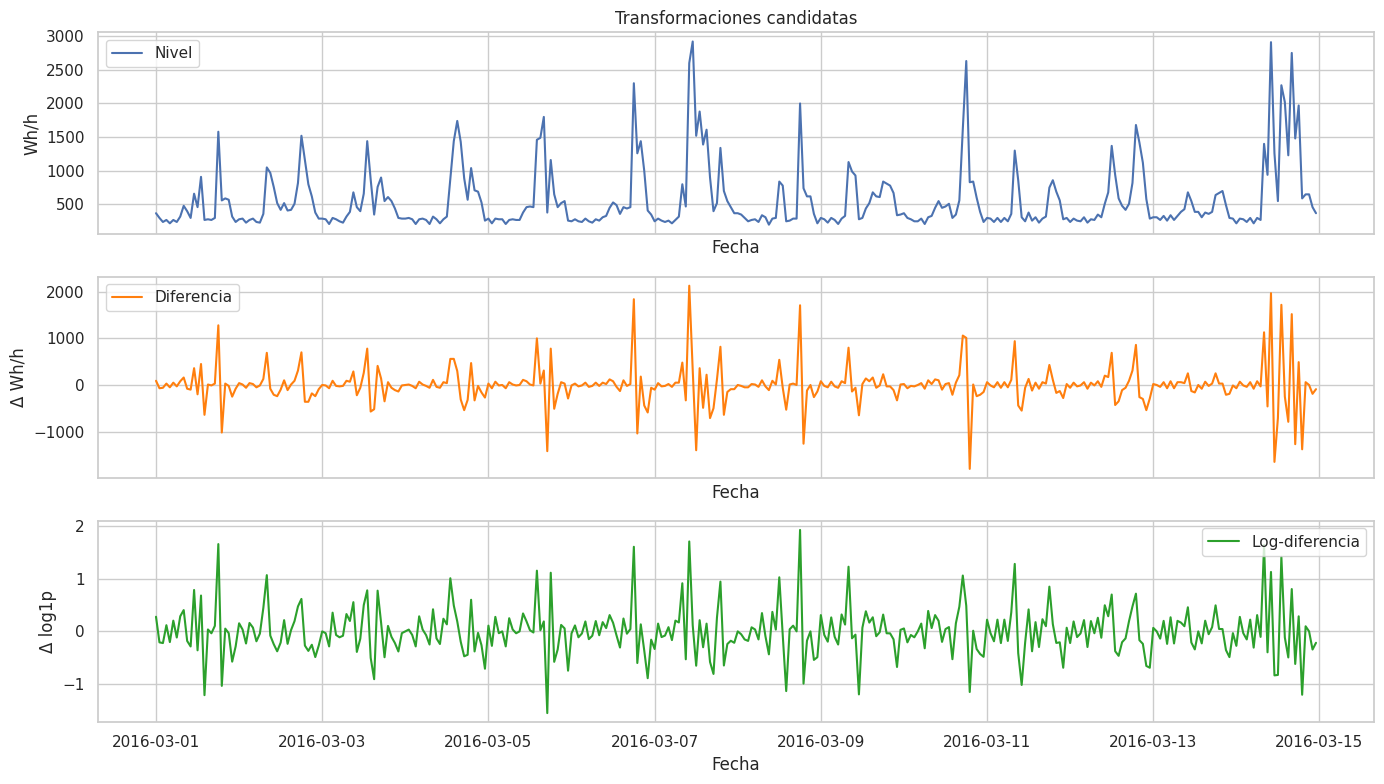

In [22]:
# Ventana común para comparar nivel, diferencia y log-diferencia
fig,axes=plt.subplots(3,1,figsize=(14,8),sharex=True); window=slice("2016-03-01","2016-03-14"); axes[0].plot(hourly.loc[window,"y"],label="Nivel"); axes[1].plot(d1.loc[window],label="Diferencia",color="tab:orange"); axes[2].plot(logd.loc[window],label="Log-diferencia",color="tab:green");
for ax,ylabel in zip(axes,["Wh/h","Δ Wh/h","Δ log1p"]): ax.set_ylabel(ylabel); ax.legend(); ax.set_xlabel("Fecha")
axes[0].set_title("Transformaciones candidatas"); plt.tight_layout(); plt.show()

### 1.12 

ACF de diferencia regular; picos diarios sugieren estructura estacional restante. Tras diferenciar, los picos en lags múltiplos de 24 indican que queda estacionalidad diaria por modelar.

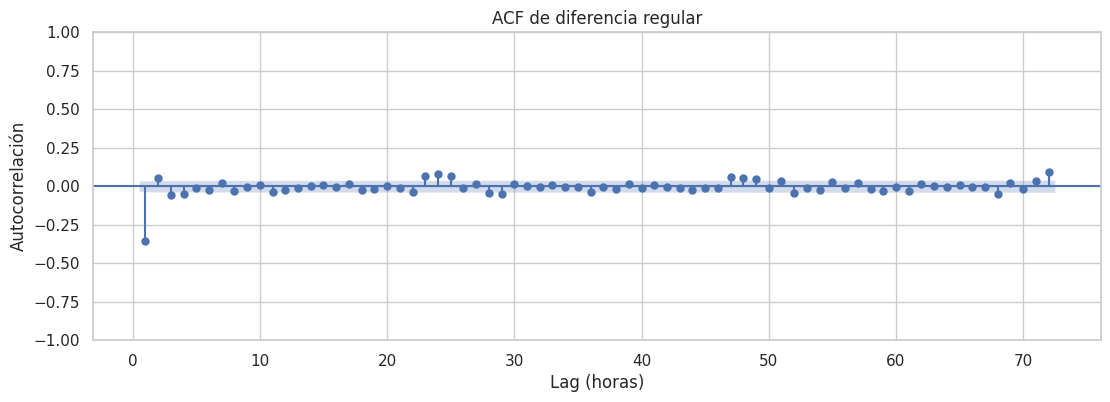

In [23]:
# ACF de la diferencia regular: picos cada 24h sugieren estacionalidad restante
fig,ax=plt.subplots(figsize=(13,4)); plot_acf(d1,lags=72,zero=False,ax=ax); ax.set(title="ACF de diferencia regular",xlabel="Lag (horas)",ylabel="Autocorrelación"); plt.show()

### 1.13 

PACF orienta p, no lo determina mecánicamente. Ayuda a elegir el orden autorregresivo en Box–Jenkins, pero la selección final se hace por AIC/BIC en train y MAE en validation.

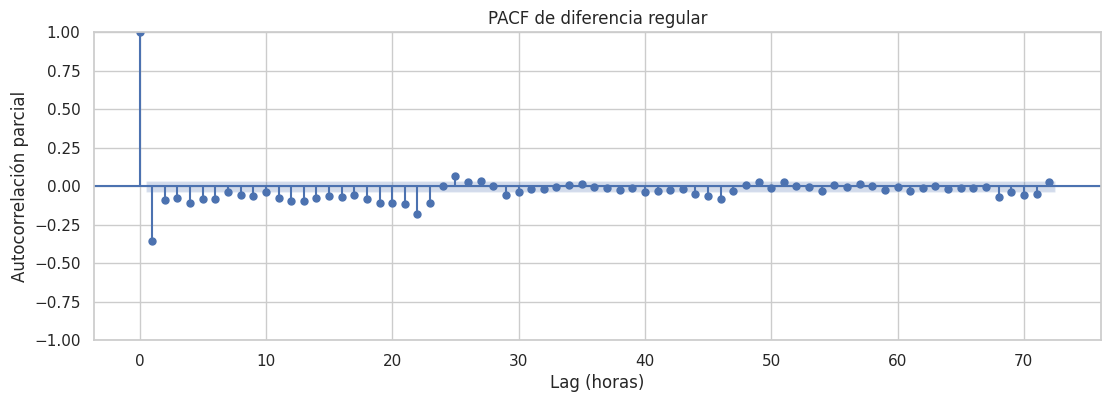

In [24]:
# PACF de la diferencia regular: orienta el orden autorregresivo p
fig,ax=plt.subplots(figsize=(13,4)); plot_pacf(d1,lags=72,method="ywm",ax=ax); ax.set(title="PACF de diferencia regular",xlabel="Lag (horas)",ylabel="Autocorrelación parcial"); plt.show()

### 1.14 

Spearman sobre sensores y target; `rv1/rv2` son controles negativos. La correlación de Spearman es monótona y robusta a outliers; si los controles negativos aparecieran correlacionados, alertarían de un artefacto del pipeline.

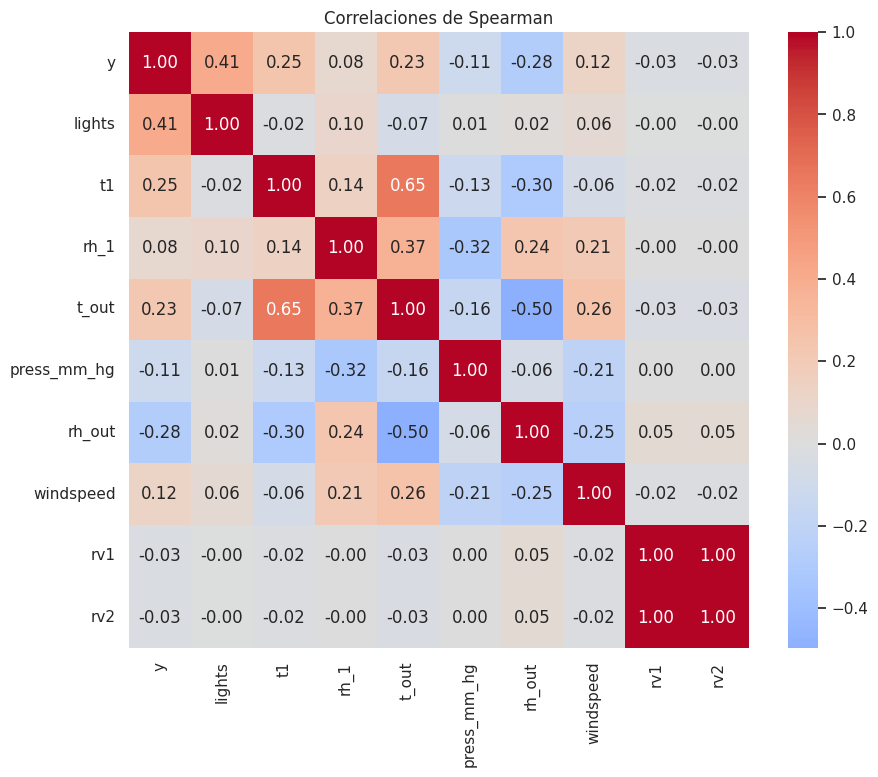

In [25]:
# Correlación de Spearman entre covariables y target (rv1/rv2: controles negativos)
cols=["y","lights","t1","rh_1","t_out","press_mm_hg","rh_out","windspeed","rv1","rv2"]
corr=hourly[cols].corr(method="spearman"); fig,ax=plt.subplots(figsize=(10,8)); sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0,ax=ax); ax.set(title="Correlaciones de Spearman"); plt.show()

### 1.15 

Se clasifica si cada covariable estaría disponible en el origen del pronóstico. Para un modelo con exógenas (ARIMAX) no basta correlacionar: hay que saber si la covariable se conocería al momento de pronosticar. Esta clasificación evita usar información futura (leakage).

In [26]:
# Disponibilidad futura de cada covariable: base para decidir ARIMAX sin leakage
feature_contract=pd.DataFrame({"feature":["calendar","weather forecast","indoor sensors contemporaneous","lights contemporaneous","rv1/rv2"],"future_availability":["known","forecast-dependent","not known unless separately forecast","target-adjacent; usually unknown","known noise but useless"],"recommendation":["use","scenario-specific","lag only","exclude for future horizon","negative control"]}); feature_contract

,feature,future_availability,recommendation
0,calendar,known,use
1,weather forecast,forecast-dependent,scenario-specific
2,indoor sensors contemporaneous,not known unless separately forecast,lag only
3,lights contemporaneous,target-adjacent; usually unknown,exclude for future horizon
4,rv1/rv2,known noise but useless,negative control


## 2. Estrategia de validación 70/15/15

- **Train (70%)** estima parámetros.
- **Validation (15%)** elige `(p,d,q)` y compara familias.
- **Test (15%)** permanece sellado hasta la selección final.

La secuencia evita ajustar hiperparámetros al test. En series temporales no se baraja: se corta por posición para respetar el orden temporal, porque cada punto depende de los anteriores.

**Aserción anti-leakage (conceptual):** ningún cálculo de train o validation toca el bloque de test; el test solo se indexa en la celda de comparación final y se consulta una única vez.

### 2.1 Cortes

Cortes por posición preservando tiempo: 70% train, 15% validation, 15% test, siempre en orden cronológico.

In [27]:
# Cortes temporales por posición: 70% train, 15% validation, 15% test
n=len(hourly); i70=int(.70*n); i85=int(.85*n); train=hourly.y.iloc[:i70]; val=hourly.y.iloc[i70:i85]; test=hourly.y.iloc[i85:]
print({"train":len(train),"validation":len(val),"test":len(test)}); print(train.index[-1],val.index[0],val.index[-1],test.index[0])

{'train': 2303, 'validation': 493, 'test': 494}
2016-04-16 15:00:00 2016-04-16 16:00:00 2016-05-07 04:00:00 2016-05-07 05:00:00


In [28]:
# Aserción anti-leakage: los tres bloques son disjuntos y respetan el orden temporal
assert train.index.isin(val.index).sum() == 0
assert train.index.isin(test.index).sum() == 0
assert val.index.isin(test.index).sum() == 0
print("Anti-leakage OK: train, validation y test no se solapan.")

Anti-leakage OK: train, validation y test no se solapan.


### 2.2 Diagrama

Visualización explícita de tres bloques. El diagrama hace visible que train, validation y test son bloques contiguos en el tiempo; el test es el bloque más reciente y permanece sellado.

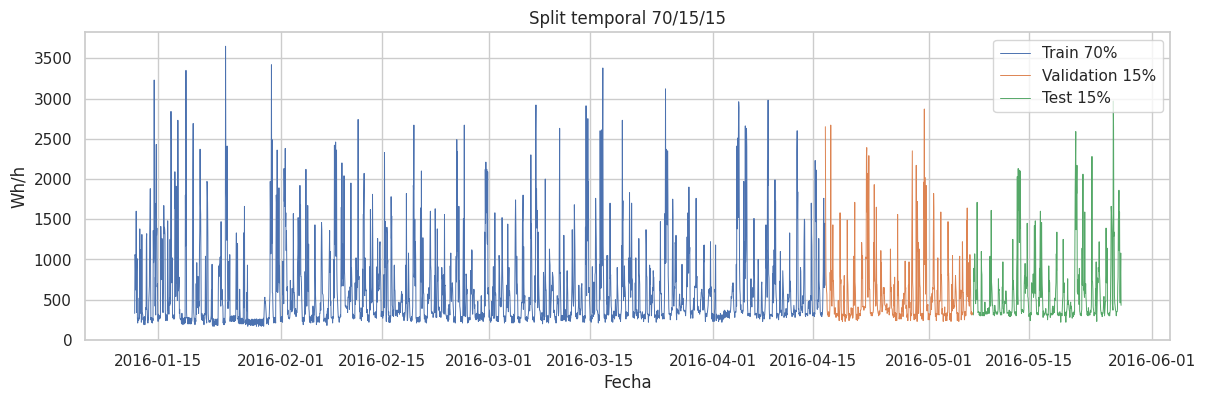

In [29]:
# Bloques temporales: train, validation y test en orden cronológico
fig,ax=plt.subplots(figsize=(14,4)); ax.plot(train.index,train,label="Train 70%",lw=.7); ax.plot(val.index,val,label="Validation 15%",lw=.7); ax.plot(test.index,test,label="Test 15%",lw=.7); ax.set(title="Split temporal 70/15/15",xlabel="Fecha",ylabel="Wh/h"); ax.legend(); plt.show()

### 2.3 Escala del horizonte

El horizonte operativo elegido es 24 horas. Coincide con la estacionalidad principal y con la necesidad de negocio de planificar el día siguiente.

In [30]:
# Horizonte operativo de 24 horas y folds completos de test
H=24; print("Horizonte:",H,"horas; folds de test posibles:",len(test)//H)

Horizonte: 24 horas; folds de test posibles: 20


## 3. Modelado

> **Methodology Card — Cuándo usar ARIMA y cuándo NO**  
> **Use ARIMA:** una serie, frecuencia regular, dependencia lineal, historia suficiente y residuos diagnosticables.  
> **Evite ARIMA solo:** múltiples estacionalidades largas, miles de series, relaciones no lineales fuertes, covariables futuras desconocidas o cambios de régimen frecuentes.  
> **Selección:** AIC/BIC en train y MAE en validation; test una sola vez.

### Box–Jenkins: las cuatro etapas del modelado

La metodología Box–Jenkins organiza la construcción de modelos ARIMA en cuatro etapas que este notebook recorre explícitamente:

1. **Identificación:** usar gráficos (ACF/PACF) y tests (ADF/KPSS) para elegir transformaciones y órdenes candidatos — Sección 1.
2. **Estimación:** ajustar los parámetros por máxima verosimilitud en train — Sección 3.
3. **Diagnóstico:** examinar los residuos del modelo ajustado — Sección 4. Si los residuos aún tienen estructura, el modelo no ha capturado todo lo explotable.
4. **Selección y uso:** elegir entre candidatos con criterios de información y validación, y usar el test una sola vez.

**¿Por qué importa el diagnóstico de residuos?** Un buen modelo debe dejar residuos que se comporten como ruido blanco. Tres tests lo verifican con lenguaje sencillo:

- **Ljung–Box:** ¿queda autocorrelación conjunta en los residuos? Si el p-value es bajo, hay estructura temporal sin capturar (p. ej., estacionalidad diaria residual).
- **Jarque–Bera:** ¿los residuos son normales? La normalidad importa para que los intervalos gaussianos de confianza sean válidos.
- **ARCH LM:** ¿la varianza de los residuos es constante? Si no, hay heterocedasticidad y las bandas de confianza pueden ser engañosas en periodos volátiles.

### 3.1 Criterios y métricas

Los criterios de información penalizan la verosimilitud por la complejidad: AIC suma 2 por parámetro extra; BIC suma log(n), una penalización mayor con n grande. Entre dos modelos con ajuste similar, se prefiere el más simple.

$$AIC=-2\log L+2k,\qquad BIC=-2\log L+k\log n$$

Las métricas se calculan en la escala original (Wh/h), la escala en la que se toman las decisiones de negocio. MASE divide el MAE por el error medio del seasonal naive diario en train: valores < 1 indican que el modelo supera a ese baseline. WAPE expresa el error como porcentaje de la demanda total.

$$MAE=\frac{1}{n}\sum|y_t-\hat y_t|,\qquad RMSE=\sqrt{\frac{1}{n}\sum(y_t-\hat y_t)^2}$$

$$MASE=\frac{MAE}{\text{mean}(|y_t-y_{t-24}|)_{train}},\qquad WAPE=100\frac{\sum|e_t|}{\sum|y_t|}

### 3.2 Función de métricas

La escala MASE usa seasonal naive diario en train. La función `metrics` resume MAE, RMSE, MASE y WAPE para cualquier par actual/pronóstico; la escala MASE se calcula en train (nunca en test) para que todos los modelos compitan en igualdad.

In [31]:
# Métricas reutilizables: MAE, RMSE, MASE y WAPE en la escala original
def metrics(actual: pd.Series,pred: pd.Series,training: pd.Series,m: int=24)->dict[str,float]:
    a=pd.concat([actual.rename("a"),pred.rename("p")],axis=1).dropna(); e=a.a-a.p; scale=training.diff(m).abs().dropna().mean()
    return {"MAE":float(e.abs().mean()),"RMSE":float(np.sqrt(np.mean(e**2))),"MASE":float(e.abs().mean()/scale),"WAPE_pct":float(100*e.abs().sum()/a.a.abs().sum())}

### 3.3 Grid de órdenes

Grid pequeño y transparente: p,q∈{0,1,2}, d∈{0,1}. Son 18 combinaciones; un grid más grande costaría más cómputo y aumentaría el riesgo de sobreajuste por selección.

In [32]:
# Grid (p,d,q): 3x2x3 = 18 modelos candidatos
orders=list(product(range(3),range(2),range(3))); print("Modelos candidatos:",len(orders))

Modelos candidatos: 18


### 3.4 Grid search AIC/BIC

Se ajusta en train. Fallos numéricos se registran; no se ocultan. Cada orden se estima por máxima verosimilitud y se guardan AIC, BIC y el estado de convergencia para que el grid sea auditable.

In [33]:
# Grid search: ajuste en train y registro de AIC, BIC y convergencia
grid=[]; t0=time.time()
for order in orders:
    try:
        fit=ARIMA(train,order=order).fit(method_kwargs={"warn_convergence":False})
        grid.append({"order":order,"aic":fit.aic,"bic":fit.bic,"converged":fit.mle_retvals.get("converged",True)})
    except Exception as exc: grid.append({"order":order,"aic":np.nan,"bic":np.nan,"converged":False,"error":str(exc)[:80]})
grid_df=pd.DataFrame(grid).sort_values("aic"); print("Segundos:",round(time.time()-t0,2)); grid_df.head(10)

Segundos: 4.6


,order,aic,bic,converged
8,"(1, 0, 2)",34211.832357,34240.542197,True
17,"(2, 1, 2)",34212.296224,34241.003892,True
14,"(2, 0, 2)",34212.317157,34246.768964,True
16,"(2, 1, 1)",34212.686640,34235.652774,True
13,"(2, 0, 1)",34220.408396,34249.118235,True
12,"(2, 0, 0)",34220.834643,34243.802515,True
11,"(1, 1, 2)",34233.011452,34255.977587,True
7,"(1, 0, 1)",34241.184217,34264.152089,True
10,"(1, 1, 1)",34303.100185,34320.324786,True
6,"(1, 0, 0)",34310.941637,34328.167541,True


### 3.5 AIC vs BIC

Ambos penalizan complejidad; BIC penaliza más con n grande. La comparación visual muestra si el top de órdenes es estable o cambia según el criterio.

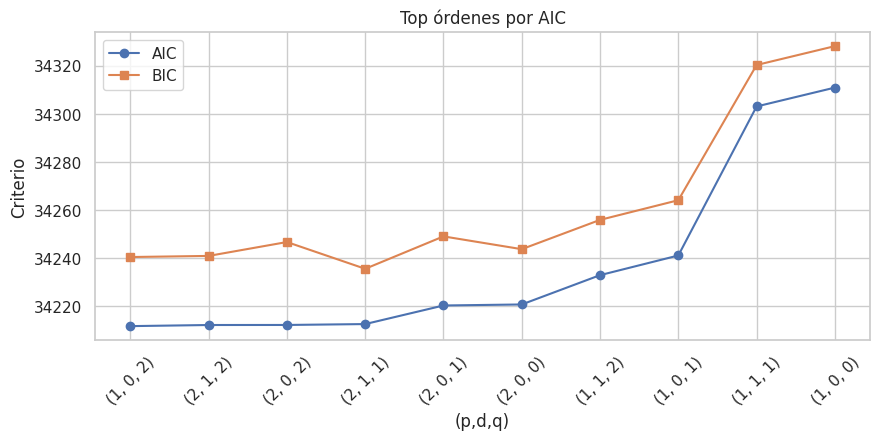

In [34]:
# Comparación AIC vs BIC en los 10 mejores por AIC
fig,ax=plt.subplots(figsize=(10,4)); top=grid_df.dropna().head(10).copy(); labels=top.order.astype(str); x=np.arange(len(top)); ax.plot(x,top.aic,marker="o",label="AIC"); ax.plot(x,top.bic,marker="s",label="BIC"); ax.set_xticks(x,labels,rotation=45); ax.set(title="Top órdenes por AIC",xlabel="(p,d,q)",ylabel="Criterio"); ax.legend(); plt.show()

### 3.6 Validación de candidatos

Se evalúan los cinco mejores AIC en validation completa. Se pronostica validation con cada candidato y se ordena por MAE de validation: la selección mide generalización sobre datos no usados para estimar, no solo ajuste en train.

In [35]:
# Validación: pronóstico de validation con los 5 mejores por AIC; orden por MAE
val_scores=[]
for order in grid_df.dropna().head(5).order:
    fit=ARIMA(train,order=order).fit(method_kwargs={"warn_convergence":False}); fc=pd.Series(fit.forecast(len(val)).values,index=val.index); val_scores.append({"order":order,**metrics(val,fc,train)})
val_table=pd.DataFrame(val_scores).sort_values("MAE"); val_table

,order,MAE,RMSE,MASE,WAPE_pct
0,"(1, 0, 2)",301.966082,425.776004,0.887391,53.904942
2,"(2, 0, 2)",302.005948,425.871732,0.887508,53.912059
4,"(2, 0, 1)",302.027112,425.937447,0.887570,53.915837
3,"(2, 1, 1)",302.032157,425.776979,0.887585,53.916737
1,"(2, 1, 2)",302.040923,425.935406,0.887611,53.918302


### 3.7 Orden seleccionado

Validation, no test, decide. El orden ganador se fija mirando solo validation; el test sigue sellado hasta la comparación final.

In [36]:
# Orden final elegido en validation; el test sigue sellado
BEST_ORDER=tuple(val_table.iloc[0].order); print("Orden ARIMA seleccionado:",BEST_ORDER)

Orden ARIMA seleccionado: (1, 0, 2)


### 3.8 Refit ARIMA

Se reentrena con train+validation antes de test. Una vez fijado el orden, se reestima con más datos (train+validation) y el modelo queda congelado para el test.

In [37]:
# Refit con train+validation: más datos para estimar el orden ya decidido
trainval=hourly.y.iloc[:i85]; arima_fit=ARIMA(trainval,order=BEST_ORDER).fit(method_kwargs={"warn_convergence":False}); arima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2796
Model:                 ARIMA(1, 0, 2)   Log Likelihood              -20703.246
Date:                Mon, 17 Aug 2026   AIC                          41416.492
Time:                        07:01:17   BIC                          41446.172
Sample:                    01-11-2016   HQIC                         41427.206
                         - 05-07-2016                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        586.9564     36.863     15.923      0.000     514.706     659.207
ar.L1          0.6392      0.024     26.122      0.000       0.591       0.687
ma.L1         -0.1749      0.026     -6.719      0.000      -0.226      -0.124
ma.L2          0.1521      0.017      9.056      0.000       0.119       0.185
sigma2      1.579e+05   2858.703     55.228      0.000    1.52e+05    1.63e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):             11550.26
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               0.68   Skew:                             2.37
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### 3.9 Forecast e intervalos

`get_forecast` entrega media e intervalos gaussianos 80%/95%. La cobertura real de esas bandas se auditará en la Sección 4: los intervalos nominales no siempre coinciden con la realidad.

In [38]:
# Pronóstico ARIMA sobre test: media e intervalos 80% y 95%
arima_res=arima_fit.get_forecast(steps=len(test)); arima_pred=pd.Series(arima_res.predicted_mean.values,index=test.index,name="ARIMA"); ci80=arima_res.conf_int(alpha=.20); ci95=arima_res.conf_int(alpha=.05); metrics(test,arima_pred,trainval)

{'MAE': 293.28228492769597,
 'RMSE': 424.40043985752175,
 'MASE': 0.9012665666927999,
 'WAPE_pct': 50.50245703927837}

### 3.10 ETS

ETS aditivo con estacionalidad diaria, ajustado en train+validation. Es el competidor más fuerte: modela la estacionalidad de forma explícita sin diferenciar la serie.

In [39]:
# ETS con tendencia amortiguada y estacionalidad diaria (periodo 24)
ets_fit=ExponentialSmoothing(trainval,trend="add",damped_trend=True,seasonal="add",seasonal_periods=24,initialization_method="estimated").fit(optimized=True,use_brute=False); ets_pred=pd.Series(ets_fit.forecast(len(test)).values,index=test.index,name="ETS"); metrics(test,ets_pred,trainval)

{'MAE': 221.7134412611615,
 'RMSE': 372.52191914191206,
 'MASE': 0.6813330441842266,
 'WAPE_pct': 38.178485772104644}

### 3.11 Theta

StatsForecast Theta con estacionalidad diaria; se usa el split temporal congelado. Combina suavizado con una recta de tendencia y usa la misma estacionalidad y el mismo split que los demás modelos: comparación justa.

In [40]:
# Theta (StatsForecast): formato long y split congelado
theta_train=pd.DataFrame({"unique_id":"energy","ds":trainval.index,"y":trainval.values}); sf=StatsForecast(models=[Theta(season_length=24)],freq="h",n_jobs=1); theta_raw=sf.forecast(df=theta_train,h=len(test)); theta_col=[x for x in theta_raw.columns if x not in ["unique_id","ds"]][0]; theta_pred=pd.Series(theta_raw[theta_col].values,index=test.index,name="Theta"); metrics(test,theta_pred,trainval)

{'MAE': 243.2632466675299,
 'RMSE': 383.6170222432923,
 'MASE': 0.7475563387016018,
 'WAPE_pct': 41.8893069763524}

### 3.12 Seasonal naive

Baseline diario alineado por timestamp. Pronostica cada hora como el valor observado 24 horas antes; ningún modelo complejo debería empeorar este punto de referencia, y MASE lo usa como denominador.

In [41]:
# Baseline seasonal naive: valor de hace 24 horas
all_y=hourly.y; sn=pd.Series([all_y.get(t-pd.Timedelta(hours=24),trainval.iloc[-1]) for t in test.index],index=test.index,name="SeasonalNaive24"); metrics(test,sn,trainval)

{'MAE': 271.47773279352225,
 'RMSE': 489.47154019816884,
 'MASE': 0.8342604267035205,
 'WAPE_pct': 46.74776910206358}

### 3.13 Comparación final

El test se consulta una vez para los modelos congelados. Es el momento clave del notebook: por primera y única vez se miran los números de test; cualquier re-selección posterior contaminaría esta medición.

In [42]:
# Comparación final en test: modelos congelados, orden por MASE
preds={"ARIMA":arima_pred,"ETS":ets_pred,"Theta":theta_pred,"SeasonalNaive24":sn}; scores=pd.DataFrame({k:metrics(test,v,trainval) for k,v in preds.items()}).T.sort_values("MASE"); scores

,MAE,RMSE,MASE,WAPE_pct
ETS,221.713441,372.521919,0.681333,38.178486
Theta,243.263247,383.617022,0.747556,41.889307
SeasonalNaive24,271.477733,489.471540,0.834260,46.747769
ARIMA,293.282285,424.400440,0.901267,50.502457


### Anti-patrón de la semana: el AIC eligió, el test decidió

**El experimento, con números del propio notebook.** AIC seleccionó ARIMA(1,0,2) como mejor orden (AIC ≈ 34211.83 en train) y validation coincidió (MAE ≈ 301.97). Pero en test, ETS ganó por MASE (0.6813) frente a ARIMA (0.9013), Theta (0.7476) y seasonal naive (0.8343); ETS también ganó en MAE (221.71 vs 293.28 Wh/h) y WAPE (38.18% vs 50.50%).

**Conclusión explícita del experimento:** el criterio de información optimiza dentro de la muestra; la validation estima generalización aproximada; solo el test (usado una vez) da la respuesta final. Que AIC elija un modelo no garantiza que gane en test: ETS, sin diferenciar, capturó la estacionalidad diaria mejor que ARIMA(1,0,2) en este dataset.

> **Pausa para pensar.** ¿Por qué un modelo "más simple" (ETS) supera a ARIMA en test aunque AIC lo penalizaba menos? ¿Qué implica para la práctica de elegir el orden por AIC sin validar?

> **Checkpoint.** Verifique que el test se ha usado una sola vez en todo el notebook (solo en la celda de comparación final) y que ningún hiperparámetro se ajustó mirando sus números.

Esto significa que AIC nos dice cuál modelo se ajusta mejor a lo que ya vimos, pero no cuál predecirá mejor lo que no hemos visto. En producción, solo importa lo segundo. La selección por AIC es una hipótesis; el test es la evidencia.

### 3.14 Forecast con intervalos

Zoom de siete días y bandas ARIMA. Las bandas anchas avisan de la incertidumbre; su cobertura empírica se audita en la Sección 4.

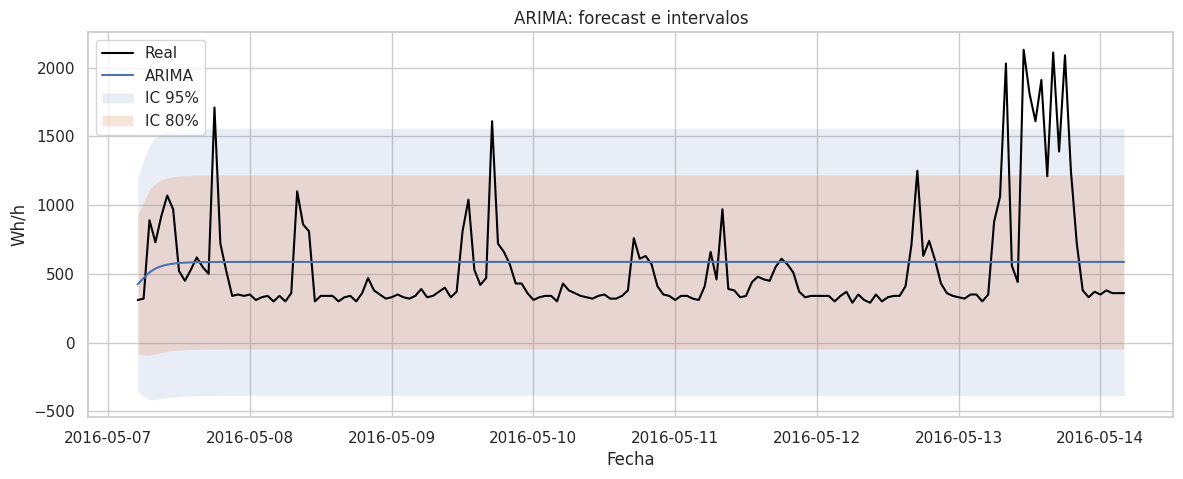

In [43]:
# Zoom semanal: real vs ARIMA con bandas 80% y 95%
z=test.index[:24*7]; lo80=pd.Series(ci80.iloc[:,0].values,index=test.index); hi80=pd.Series(ci80.iloc[:,1].values,index=test.index); lo95=pd.Series(ci95.iloc[:,0].values,index=test.index); hi95=pd.Series(ci95.iloc[:,1].values,index=test.index)
fig,ax=plt.subplots(figsize=(14,5)); ax.plot(z,test.loc[z],color="black",label="Real"); ax.plot(z,arima_pred.loc[z],label="ARIMA"); ax.fill_between(z,lo95.loc[z],hi95.loc[z],alpha=.12,label="IC 95%"); ax.fill_between(z,lo80.loc[z],hi80.loc[z],alpha=.22,label="IC 80%"); ax.set(title="ARIMA: forecast e intervalos",xlabel="Fecha",ylabel="Wh/h"); ax.legend(); plt.show()

## 4. Análisis posterior (diagnóstico de residuos)

El diagnóstico Box–Jenkins pregunta si los residuos del modelo ajustado se aproximan a ruido blanco. Normalidad y homocedasticidad afectan especialmente los intervalos gaussianos: si los residuos no son normales o su varianza cambia, las bandas de confianza pierden validez nominal.

### 4.1 Residuos in-sample

Se descarta el burn-in inicial según el máximo orden. Las primeras observaciones del filtro ARIMA aún se están estabilizando; descartarlas evita que contaminen el diagnóstico.

In [44]:
# Residuos in-sample de ARIMA sin el burn-in inicial
resid=arima_fit.resid.dropna(); resid=resid.iloc[max(30,sum(BEST_ORDER)):]; print(resid.describe())

count    2766.000000
mean       -0.014636
std       397.220688
min     -1512.405658
25%      -154.323758
50%       -90.045442
75%         1.860018
max      3198.996333
dtype: float64


### 4.2 Residuos en el tiempo

Debe oscilar alrededor de cero sin patrón. Si el modelo capturó la estructura, los residuos son ruido alrededor de cero; clusters de volatilidad o deriva serían señales de diagnóstico.

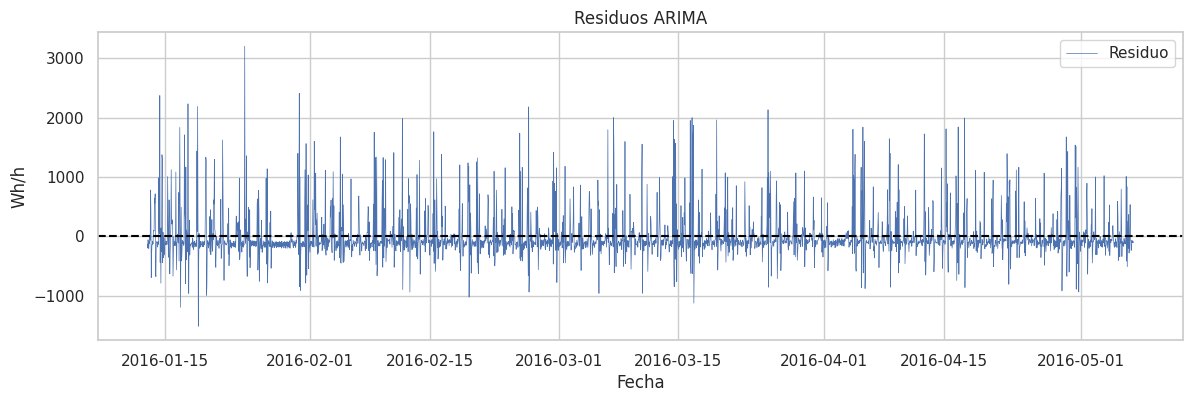

In [45]:
# Serie temporal de residuos: se busca ausencia de patrón
fig,ax=plt.subplots(figsize=(14,4)); ax.plot(resid.index,resid,lw=.5,label="Residuo"); ax.axhline(0,color="black",ls="--"); ax.set(title="Residuos ARIMA",xlabel="Fecha",ylabel="Wh/h"); ax.legend(); plt.show()

### 4.3 Ljung–Box

H₀: no autocorrelación conjunta hasta cada lag. En el output se ve el patrón típico de este notebook: en lag 10 no se rechaza H₀ (p≈0.73), pero en lag 20 (p≈0.001) y lag 30 (p≈3.7e-31) sí: queda estructura diaria sin capturar.

In [46]:
# Ljung-Box: autocorrelación conjunta de residuos en lags 10, 20 y 30
lb=acorr_ljungbox(resid,lags=[10,20,30],return_df=True).rename(columns={"lb_stat":"stat","lb_pvalue":"p_value"}); lb["H0"]="sin autocorrelación"; lb["decision_alpha_0.05"]=np.where(lb.p_value<.05,"rechazar H0","no rechazar H0"); lb

,stat,p_value,H0,decision_alpha_0.05
10,6.951762,7.299909e-01,sin autocorrelación,no rechazar H0
20,44.987460,1.107798e-03,sin autocorrelación,rechazar H0
30,221.908614,3.653526e-31,sin autocorrelación,rechazar H0


### 4.4 QQ-plot

Evalúa colas respecto a normal. Los puntos deben alinearse en la diagonal; desviaciones en los extremos indican colas pesadas (más errores grandes de lo esperado bajo normalidad).

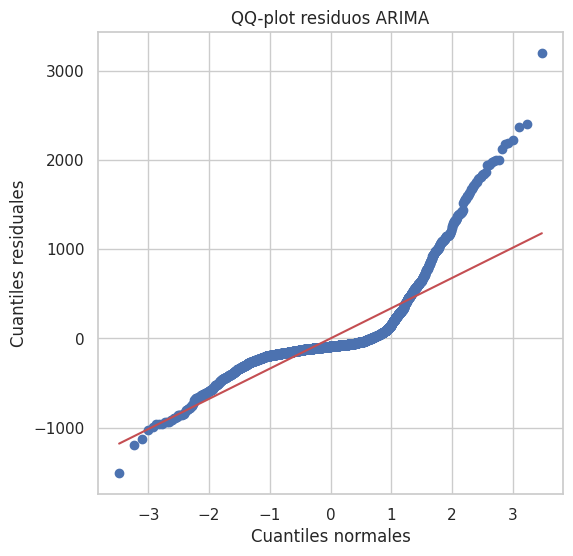

In [47]:
# QQ-plot: desviaciones de normalidad en las colas
fig,ax=plt.subplots(figsize=(6,6)); stats.probplot(resid,dist="norm",plot=ax); ax.set(title="QQ-plot residuos ARIMA",xlabel="Cuantiles normales",ylabel="Cuantiles residuales"); plt.show()

### 4.5 Jarque–Bera

H₀: normalidad. Con n grande detecta desviaciones leves. El output rechaza H₀ (p≈0) con asimetría ≈2.39 y curtosis ≈11.89, coherente con las colas del QQ-plot.

In [48]:
# Jarque-Bera: normalidad de residuos (asimetría y curtosis)
jb=jarque_bera(resid); pd.DataFrame([{"test":"Jarque-Bera","H0":"normalidad","stat":jb[0],"p_value":jb[1],"decision":"rechazar H0" if jb[1]<.05 else "no rechazar H0","skew":jb[2],"kurtosis":jb[3]}])

,test,H0,stat,p_value,decision,skew,kurtosis
0,Jarque-Bera,normalidad,11750.736685,0.0,rechazar H0,2.393216,11.890936


### 4.6 ARCH LM

H₀: no heterocedasticidad ARCH hasta 24 lags. El output rechaza H₀ (p≈2e-18): hay clusters de volatilidad, y los intervalos gaussianos de ARIMA pueden subestimar la incertidumbre en periodos agitados.

In [49]:
# ARCH LM: heterocedasticidad condicional hasta 24 lags
arch=het_arch(resid,nlags=24); pd.DataFrame([{"test":"ARCH LM","H0":"homocedasticidad condicional","stat":arch[0],"p_value":arch[1],"decision":"rechazar H0" if arch[1]<.05 else "no rechazar H0"}])

,test,H0,stat,p_value,decision
0,ARCH LM,homocedasticidad condicional,140.398575,1.968100e-18,rechazar H0


### 4.7 Histograma residual

La forma ayuda a interpretar el QQ-plot. La cola derecha visible explica la asimetría positiva y la curtosis alta reportadas por Jarque–Bera.

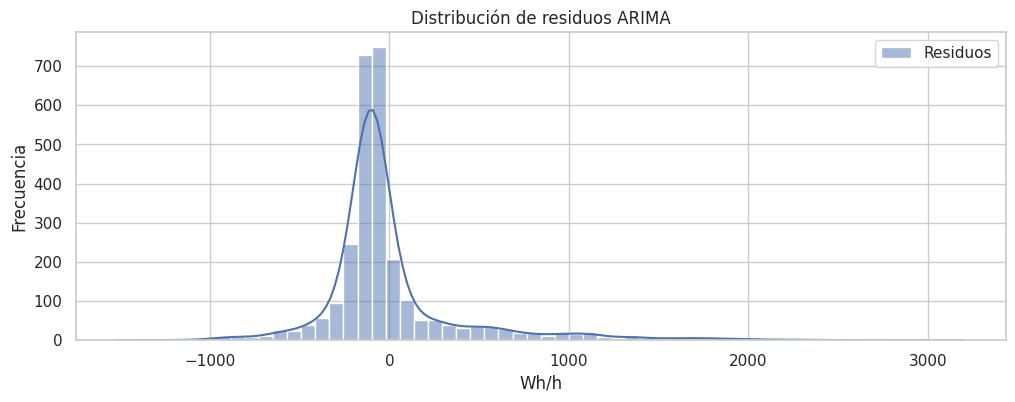

In [50]:
# Histograma de residuos: forma de la distribución
fig,ax=plt.subplots(); sns.histplot(resid,bins=60,kde=True,ax=ax,label="Residuos"); ax.set(title="Distribución de residuos ARIMA",xlabel="Wh/h",ylabel="Frecuencia"); ax.legend(); plt.show()

### 4.8 Cobertura intervalos

Cobertura empírica se compara con 80% y 95%. En el output: 80% nominal → 91.09% empírico (banda conservadora) y 95% nominal → 94.94% (muy cercana a la nominal). La cobertura no es exacta porque los residuos no son normales ni homocedásticos.

In [51]:
# Cobertura empírica de los intervalos ARIMA en test
coverage80=np.mean((test.values>=lo80.values)&(test.values<=hi80.values)); coverage95=np.mean((test.values>=lo95.values)&(test.values<=hi95.values)); pd.DataFrame({"nominal":[.80,.95],"empirical":[coverage80,coverage95]})

,nominal,empirical
0,0.80,0.910931
1,0.95,0.949393


### 4.9 Error por horizonte

Horizonte dentro de cada día de 24 horas. Muestra si el error crece con el horizonte (típico en ARIMA) o si hay horas especialmente difíciles.

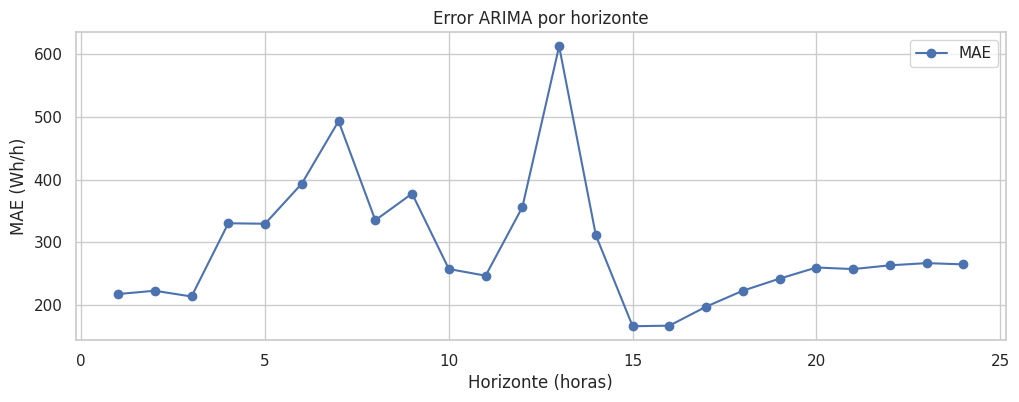

In [52]:
# MAE y sesgo por horizonte dentro del día de pronóstico
err=pd.DataFrame({"error":test-arima_pred}); err["horizon"]=(np.arange(len(err))%24)+1; by_h=err.groupby("horizon").error.agg(MAE=lambda x:x.abs().mean(),Bias="mean"); fig,ax=plt.subplots(); ax.plot(by_h.index,by_h.MAE,marker="o",label="MAE"); ax.set(title="Error ARIMA por horizonte",xlabel="Horizonte (horas)",ylabel="MAE (Wh/h)"); ax.legend(); plt.show()

### 4.10 Picos vs valles

Segmentos definidos por cuantiles del test; es análisis descriptivo post hoc. El output muestra que el error medio en picos (≈572 Wh/h) casi duplica al de valles (≈275 Wh/h): el modelo falla más justo donde el negocio más lo sufre (alertas de pico).

In [53]:
# Error absoluto por segmento (valle/medio/pico) según cuantiles del test
q25,q75=test.quantile([.25,.75]); segment=pd.cut(test,[-np.inf,q25,q75,np.inf],labels=["valle","medio","pico"]); seg=pd.DataFrame({"abs_error":(test-arima_pred).abs(),"segment":segment}); seg.groupby("segment",observed=True).abs_error.agg(["mean","median","count"])

,mean,median,count
segment,,,
valle,274.893042,276.956359,126
medio,162.748098,196.956359,245
pico,572.127167,378.319249,123


### 4.11 Error por hora

Detecta franjas problemáticas. Si el error se concentra en horas concretas (p. ej., arranque de mañana o pico de noche), es información accionable para priorizar modelos o activar alertas.

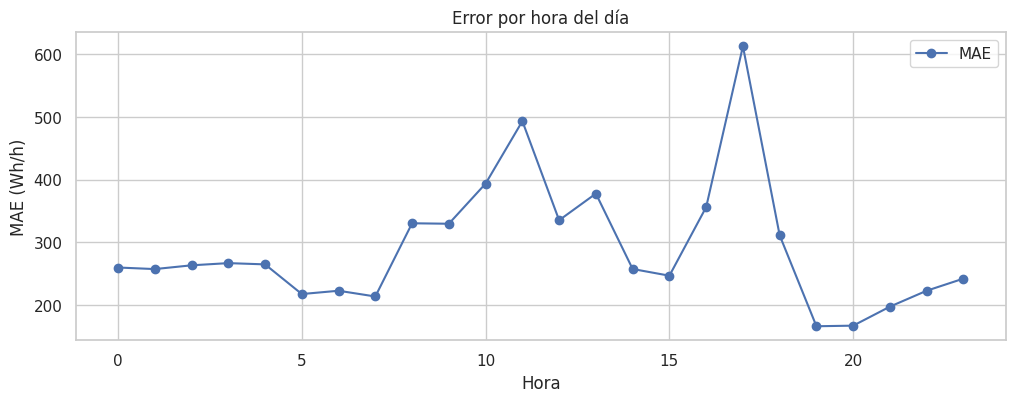

In [54]:
# Error medio por hora del día: franjas problemáticas
eh=pd.DataFrame({"abs_error":(test-arima_pred).abs(),"hour":test.index.hour}).groupby("hour").abs_error.mean(); fig,ax=plt.subplots(); ax.plot(eh.index,eh,marker="o",label="MAE"); ax.set(title="Error por hora del día",xlabel="Hora",ylabel="MAE (Wh/h)"); ax.legend(); plt.show()

### 4.12 Forecast vs real

Zoom en tres días con los cuatro modelos. La comparación visual complementa la tabla de métricas y ayuda a explicar por qué ETS sigue mejor el ciclo diario.

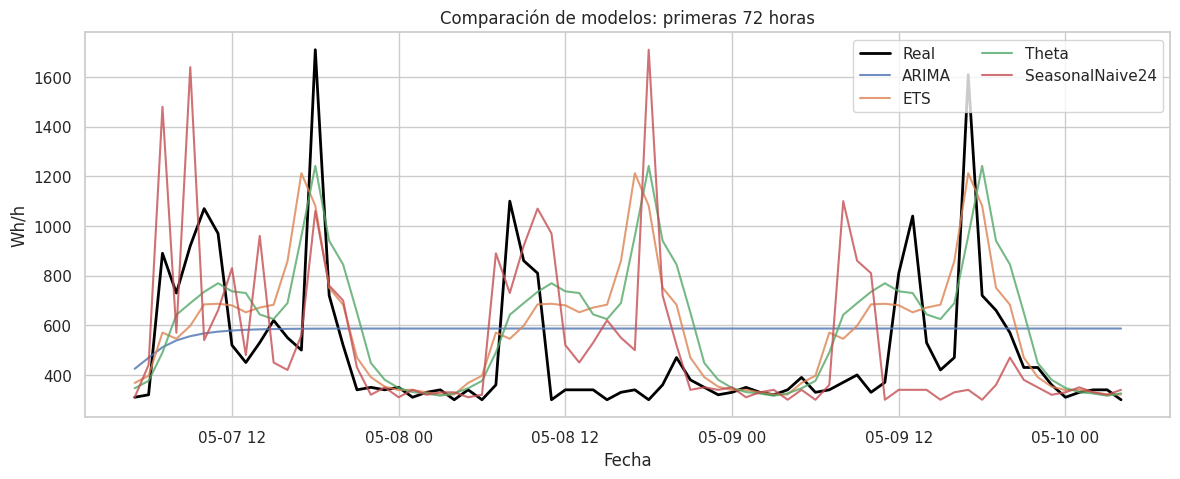

In [55]:
# Comparación visual de los cuatro modelos en las primeras 72 horas de test
z=test.index[:72]; fig,ax=plt.subplots(figsize=(14,5)); ax.plot(z,test.loc[z],color="black",lw=2,label="Real");
for name,p in preds.items(): ax.plot(z,p.loc[z],label=name,alpha=.8)
ax.set(title="Comparación de modelos: primeras 72 horas",xlabel="Fecha",ylabel="Wh/h"); ax.legend(ncol=2); plt.show()

## 5. Lecciones metodológicas

1. ADF y KPSS tienen hipótesis distintas; use ambos y gráficos.  
2. AIC/BIC seleccionan dentro de una familia, pero validation estima generalización.  
3. El test no participa en el grid search.  
4. Residuos autocorrelacionados indican estructura no capturada.  
5. Picos, colas y heterocedasticidad degradan intervalos gaussianos.  
6. ARIMAX exige covariables futuras disponibles o pronosticadas.  
7. La evidencia de test de esta semana (ETS MASE 0.6813 vs ARIMA 0.9013) recuerda que un buen diagnóstico no convierte a un modelo en ganador: la comparación honesta en test manda.

**Conexión:** Semana 3 incorpora exógenas explícitas con SARIMAX y rolling-origin.

### Decisión ejecutiva

Con la evidencia del test (una sola consulta), la recomendación para el caso de negocio es:

- **Modelo operativo:** preferir **ETS** por robustez: ganó en MASE (0.6813), MAE (221.71 Wh/h) y WAPE (38.18%) frente a ARIMA, Theta y el seasonal naive, y su comportamiento visual sigue mejor el ciclo diario.
- **ARIMA queda como referencia diagnóstica:** su diagnóstico de residuos (Ljung–Box, Jarque–Bera, ARCH LM) muestra estructura no capturada y colas pesadas; no se descarta en general, pero en este dataset rinde peor en test.
- **Riesgo documentado:** sobre-optimizar criterios de información (AIC/BIC) o re-consultar el test para re-seleccionar infla el optimismo; la selección se hace en validation y el test se usa una sola vez.
- **Acción de seguimiento:** si el error en picos (≈572 Wh/h de MAE en el segmento pico) es costoso para alertas de demanda, evaluar modelos que reduzcan ese error específico (p. ej., SARIMA con estacionalidad explícita, Semana 3).

### Checklist de reproducibilidad

- [ ] Mismo dataset (`data/02_energy/energy.csv`, 19,735 filas × 29 columnas) y misma ruta portable.
- [ ] Misma semilla (`seed=42`) y mismos imports.
- [ ] Mismo split temporal 70/15/15 por posición y horizonte H=24.
- [ ] Mismo grid de órdenes (p,q∈{0,1,2}, d∈{0,1}) y misma selección: AIC en train, MAE en validation, test una sola vez.
- [ ] Misma escala MASE (seasonal naive diario en train) para todas las métricas.
- [ ] Salidas esperadas: grid de AIC/BIC, tabla de validation, tabla final de test y diagnósticos de residuos reproducibles con las versiones de `statsmodels`/`statsforecast` utilizadas.

> **Lectura operativa:** MASE 0.6813 significa que el error de ETS es el 68.1 % del error que cometeríamos repitiendo el consumo de la misma hora de la semana pasada. En MAE, ETS se equivoca en promedio 221.71 Wh/h frente a 293.28 Wh/h del seasonal naive. La pregunta operativa es si esa reducción justifica mantener un modelo ARIMA/ETS en producción frente a la regla simple.

> **Lo que este análisis NO puede afirmar:** que el consumo energético está determinado por las variables del dataset (solo muestra correlación temporal); que el patrón observado se mantendrá si cambian las condiciones de la vivienda (ocupación, clima extremo, renovación de equipos); ni que ETS es "mejor" en absoluto — es mejor *en este dataset, con este protocolo, en este período de test*.

## 6. Ejercicios

1. **Fácil:** amplíe el grid a p,q≤3 y compare AIC, BIC y validation MAE.  
2. **Intermedio:** agregue componente estacional SARIMA diario.  
3. **Intermedio:** use `t_out` rezagada en ARIMAX y documente disponibilidad.  
4. **Difícil:** construya intervalos bootstrap respetando bloques diarios.  
5. **Difícil:** evalúe estabilidad de órdenes en tres orígenes temporales.

In [56]:
# Cierre: resumen de la decisión final
print("Notebook 2 completado.")
print("Orden ARIMA:",BEST_ORDER)
print("Mejor modelo en test por MASE:",scores.index[0])

Notebook 2 completado.
Orden ARIMA: (1, 0, 2)
Mejor modelo en test por MASE: ETS
